Analysing the performance of various quantum probe states, such as squeezed and coherent states, for estimating spacetime parameters like the Schwarzschild radius when operating within a channel subject to both loss and noise.

Calculating for: Low Noise ($V_{noise}=0.01$)
Calculating for: Medium Noise ($V_{noise}=0.6$)
Calculating for: High Noise ($V_{noise}=1.5$)


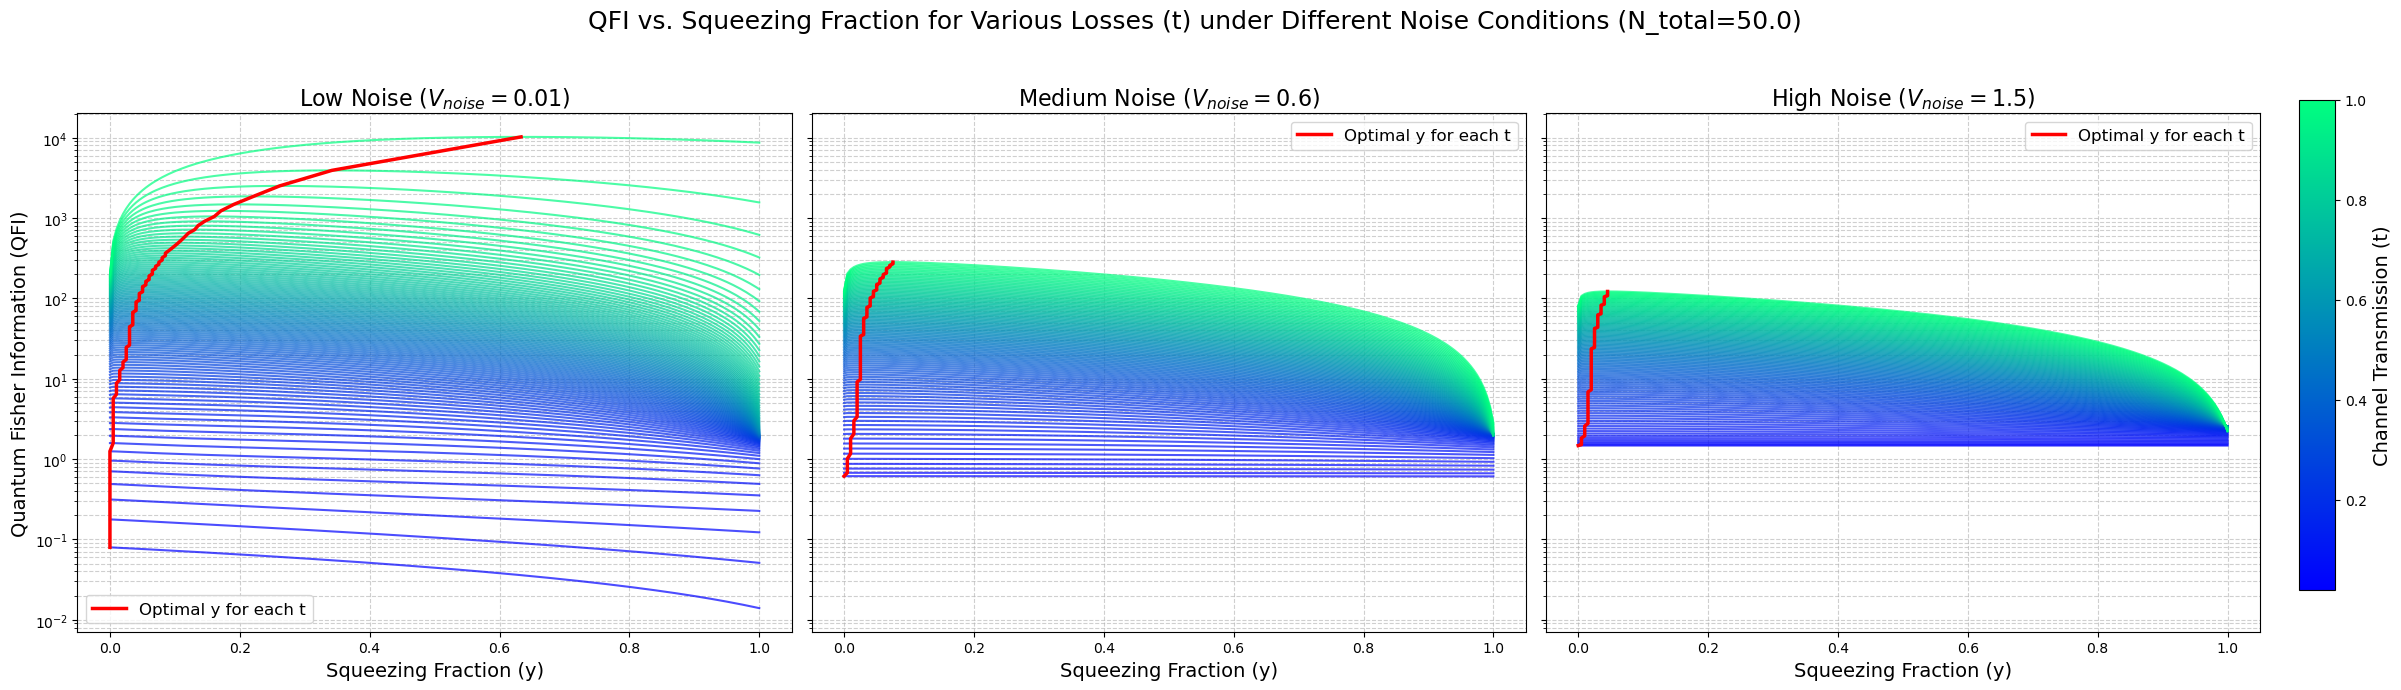

In [1]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt

# Constants
N_TOTAL = 50.0  # Total mean photon number
THETA_PARAM = 1.0 - 1.0e-9  # (Gravitational) parameter

# Noises
noises = {
    'Low Noise ($V_{noise}=0.01$)': 0.01,  # 0 noise ~ shot noise
    'Medium Noise ($V_{noise}=0.6$)': 0.6,  
    'High Noise ($V_{noise}=1.5$)': 1.5
}

# Define funtions for V and QFI
def calculate_final_variances(Theta, t, r, V_noise):
    """
    Calculates the final variances (V1+, V1-) for a squeezed state with squeezed angle=0.
    """
    var_X_in = np.exp(-2 * r)
    var_P_in = np.exp(2 * r)
    
    V1_plus = Theta**2 * (t**2 * var_X_in + 1 - t**2 + V_noise) + 1 - Theta**2
    V1_minus = Theta**2 * (t**2 * var_P_in + 1 - t**2 + V_noise) + 1 - Theta**2
    
    return V1_plus, V1_minus

def calculate_qfi(N_coherent, Theta, t, r, V_noise):

    V1_plus, V1_minus = calculate_final_variances(Theta, t, r, V_noise)
    
    dV1_plus_dTheta = 2 * Theta * (t**2 * (np.exp(-2 * r) - 1) + V_noise)
    dV1_minus_dTheta = 2 * Theta * (t**2 * (np.exp(2 * r) - 1) + V_noise)
    

    K_displacement = t**2 * N_coherent / V1_plus
    
    # K_shape corresponds to the term from the change in the noise ellipse shape
    K_shape_plus_term = (dV1_plus_dTheta / V1_plus)**2
    K_shape_minus_term = (dV1_minus_dTheta / V1_minus)**2
    K_shape = (1/8) * (K_shape_plus_term + K_shape_minus_term)
    
    # Step 3: The QFI is 4 times the sum of these two fidelity terms
    total_qfi = 4 * (K_displacement + K_shape)
    
    return total_qfi

# Create 2D grids for loss (t) and squeezing fraction (y)
y_values = np.linspace(0, 1, 200)
t_values = np.linspace(0.02, 1.00, 100)
T_grid, Y_grid = np.meshgrid(t_values, y_values)

# Calculate r and N_coherent for the entire grid
Y_grid[Y_grid >= 1.0] = 0.99999
R_grid = np.arcsinh(np.sqrt(Y_grid * N_TOTAL))
N_coherent_grid = (1 - Y_grid) * N_TOTAL

# Create a figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(24, 7), sharey=True)
fig.suptitle(f'QFI vs. Squeezing Fraction for Various Losses (t) under Different Noise Conditions (N_total={N_TOTAL})', fontsize=18)

# Loop through each noise and create a subplot
for i, (title, v_n) in enumerate(noises.items()):
    ax = axes[i]
    print(f"Calculating for: {title}")
    
    # Calculate the QFI for every (t, y)
    qfi_matrix = calculate_qfi(N_coherent_grid, THETA_PARAM, T_grid, R_grid, v_n)
    
    colors = plt.cm.winter(np.linspace(0, 1, len(t_values)))

    # Plot a curve (QFI vs y) for each value of t
    for j in range(len(t_values)):
        ax.plot(y_values, qfi_matrix[:, j], color=colors[j], alpha=0.7)

    # Find and plot the optimal y for each t (the red line)
    max_qfi_values = np.max(qfi_matrix, axis=0)
    optimal_y_indices = np.argmax(qfi_matrix, axis=0)
    optimal_y_values = y_values[optimal_y_indices]
    ax.plot(optimal_y_values, max_qfi_values, 'r-', linewidth=2.5, label=f'Optimal y for each t')
    ax.set_yscale('log')
    ax.set_xlabel('Squeezing Fraction (y)', fontsize=14)
    ax.set_title(title, fontsize=16)
    ax.grid(True, which="both", ls="--", alpha=0.6)
    ax.legend(fontsize=12)

axes[0].set_ylabel('Quantum Fisher Information (QFI)', fontsize=14)

plt.tight_layout(rect=[0, 0, 0.95, 0.95])
norm = plt.Normalize(vmin=t_values.min(), vmax=t_values.max())
sm = plt.cm.ScalarMappable(cmap=plt.cm.winter, norm=norm)
sm.set_array([])
cbar_ax = fig.add_axes([0.96, 0.15, 0.015, 0.7])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label('Channel Transmission (t)', fontsize=14)

plt.show()

* High Transmission (t ≈ 1): In this regime, additive noise primarily acts to decohere the probe state, resulting in a net loss of information and a decrease in the Quantum Fisher Information (QFI).
* Low Transmission (t ≈ 0): Here, the initial probe is lost to the vacuum, and the additive noise itself becomes the information carrier, increasing the QFI from a near-zero baseline.

C:\Users\biamj\AppData\Local\Temp\ipykernel_47596\2665073909.py:38: RuntimeWarning: divide by zero encountered in divide
  schwarzschild_error = np.where(denominator > 1e-20, 1.0 / denominator, np.inf)
C:\Users\biamj\AppData\Local\Temp\ipykernel_47596\2665073909.py:60: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=12)


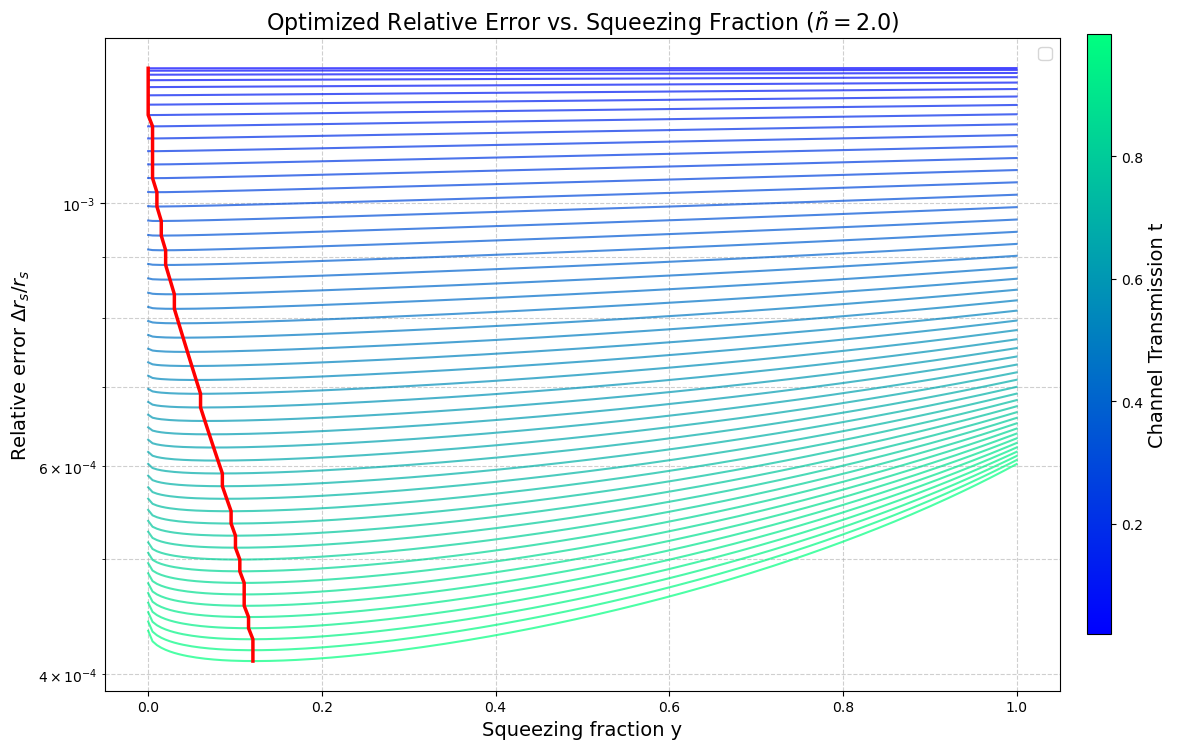

In [10]:
# Constants
N_tot = 2.0      # Total mean photon number, as in Fig. 8
N = 200.0      # Number of measurements
sigma_0 = 2000.0 
omega_0 = 700e12 
r_A = 6.37e6
r_B = 42.0e6
r_s = 0.00887
L = r_B - r_A
delta = (r_s / 2) * L / (r_A * r_B)

# Noise added 
V_NOISE = 1

y_1d = np.linspace(0, 1, 200)
t_1d = np.linspace(0.02, 0.999999, 50) 
epsilon_values = np.linspace(0, 2 * delta, 100).reshape(-1, 1, 1) # list of epsilon values 
Y, T = np.meshgrid(y_1d, t_1d, indexing='ij')

# Set figure
fig, ax = plt.subplots(figsize=(12, 8))

# Relationship between N_tot, r, and alpha
R = np.arcsinh(np.sqrt(Y * N_tot))
ALPHA_SQ = (1 - Y) * N_tot

# Calculate Theta and its derivative for all epsilons
x = ((delta - epsilon_values)**2 * omega_0**2) / (8 * sigma_0**2)
Theta = np.exp(-x)
dTheta_drs = -((delta - epsilon_values) * omega_0**2 * delta) / (4 * sigma_0**2 * r_s) * np.exp(-x)

H = calculate_qfi(ALPHA_SQ, Theta, T, R, V_NOISE) # QFI

denominator = r_s * np.abs(dTheta_drs) * np.sqrt(N * H)
schwarzschild_error = np.where(denominator > 1e-20, 1.0 / denominator, np.inf)

# Find the minimum error along the epsilon axis (getting 2D error_matrix)
error_matrix = np.min(schwarzschild_error, axis=0)

# Plotting
colors = plt.cm.winter(np.linspace(0, 1, len(t_1d)))
for i in range(len(t_1d)):
    ax.plot(y_1d, error_matrix[:, i], color=colors[i], alpha=0.7)

# Find and plot the optimal y for each t (the red line)
min_error_values = np.min(error_matrix, axis=0)
optimal_y_indices = np.argmin(error_matrix, axis=0)
optimal_y_points = y_1d[optimal_y_indices]
ax.plot(optimal_y_points, min_error_values, 'r-', linewidth=2.5)
ax.set_yscale('log')
ax.set_xlabel(r'Squeezing fraction y', fontsize=14)
ax.set_ylabel(r'Relative error $\Delta r_s/r_s$', fontsize=14)
ax.set_title(f'Optimized Relative Error vs. Squeezing Fraction ($\\tilde{{n}}={N_tot}$)', fontsize=16)
ax.grid(True, which="both", ls="--", alpha=0.6)
ax.legend(fontsize=12)

plt.tight_layout(rect=[0, 0, 0.9, 0.95])
norm = plt.Normalize(vmin=t_1d.min(), vmax=t_1d.max())
sm = plt.cm.ScalarMappable(cmap=plt.cm.winter, norm=norm)
sm.set_array([])
cbar_ax = fig.add_axes([0.91, 0.15, 0.02, 0.75])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label('Channel Transmission t', fontsize=14)

plt.show()

* Figure above shows the relationship between the QFI and y for various t under condition V_noise = 1
* This method does not hold for V_noise = 0. This is possibly due to the approximations during taylor expansion. Theoretically, V_noise =0 should be reduced to equation 19 in 2016 paper and produce figure 8. 